In [1]:
import pandas as pd


In [2]:
transactions_df = pd.read_csv('/content/Retail_Data_Transactions.csv')
response_df = pd.read_csv('/content/Retail_Data_Response.csv')


In [3]:
# Check missing values in transactions
print("Missing values in transactions:")
print(transactions_df.isnull().sum())

# Check missing values in responses
print("\nMissing values in responses:")
print(response_df.isnull().sum())


Missing values in transactions:
customer_id    0
trans_date     0
tran_amount    0
dtype: int64

Missing values in responses:
customer_id    0
response       0
dtype: int64


In [4]:
# Convert 'trans_date' to datetime
transactions_df['trans_date'] = pd.to_datetime(transactions_df['trans_date'], format='%d-%b-%y', errors='coerce')

# Convert 'tran_amount' to numeric
transactions_df['tran_amount'] = pd.to_numeric(transactions_df['tran_amount'], errors='coerce')

# Ensure 'response' is integer
response_df['response'] = response_df['response'].astype('Int64')


In [5]:
# Drop rows where important fields are missing
transactions_df = transactions_df.dropna(subset=['customer_id', 'trans_date', 'tran_amount'])
response_df = response_df.dropna(subset=['customer_id', 'response'])


In [6]:
# Remove duplicates if any
transactions_df = transactions_df.drop_duplicates()
response_df = response_df.drop_duplicates()


In [7]:
# Load data (update the path as needed)
transactions_df = pd.read_csv("Retail_Data_Transactions.csv")

# Step 1: Convert trans_date to datetime
transactions_df['trans_date'] = pd.to_datetime(transactions_df['trans_date'], format='%d-%b-%y', errors='coerce')

# Step 2: Extract year and month
transactions_df['year'] = transactions_df['trans_date'].dt.year
transactions_df['month'] = transactions_df['trans_date'].dt.month

# Step 3: Calculate total transaction amount per customer
customer_total_spend = transactions_df.groupby('customer_id')['tran_amount'].sum().reset_index()
customer_total_spend.rename(columns={'tran_amount': 'total_spent'}, inplace=True)

# Step 4: Tag high spenders (e.g., those spending > ₹100)
customer_total_spend['high_spender'] = customer_total_spend['total_spent'] > 100

# Step 5: Merge back to transaction data
transactions_df = pd.merge(transactions_df, customer_total_spend, on='customer_id', how='left')

# Preview the result
print(transactions_df.head())

  customer_id trans_date  tran_amount  year  month  total_spent  high_spender
0      CS5295 2013-02-11           35  2013      2         1637          True
1      CS4768 2015-03-15           39  2015      3         1721          True
2      CS2122 2013-02-26           52  2013      2         1648          True
3      CS1217 2011-11-16           99  2011     11         1431          True
4      CS1850 2013-11-20           78  2013     11         1908          True


In [8]:
# Load the response data
response_df = pd.read_csv("Retail_Data_Response.csv")

# Merge both datasets on customer_id
merged_df = pd.merge(transactions_df, response_df, on='customer_id', how='inner')


In [9]:
# Total number of Transactions
total_transactions = merged_df.shape[0]
print(f"Total Transactions: {total_transactions}")


Total Transactions: 124969


In [10]:
#Total and Average Transaction Value
print("Total Sales:", merged_df['tran_amount'].sum())
print("Average Transaction Value:", merged_df['tran_amount'].mean())


Total Sales: 8122378
Average Transaction Value: 64.99514279541326


In [12]:
#Responders vs Non-Responders
print(merged_df['response'].value_counts())


response
0    111127
1     13842
Name: count, dtype: int64


In [13]:
#Compare Spend of Responders vs Non-Responders
avg_spend_by_response = merged_df.groupby('response')['tran_amount'].mean()
print("Average Spend by Response Group:\n", avg_spend_by_response)


Average Spend by Response Group:
 response
0    64.492248
1    69.032510
Name: tran_amount, dtype: float64


In [14]:
# Sales Trend Over Time
monthly_sales = merged_df.groupby(['year', 'month'])['tran_amount'].sum().reset_index()
monthly_sales['period'] = pd.to_datetime(monthly_sales[['year', 'month']].assign(day=1))


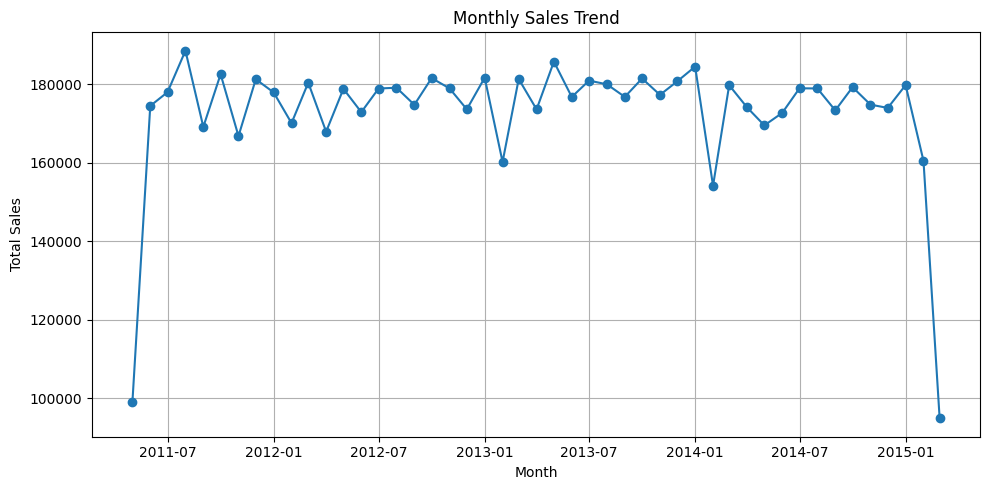

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales['period'], monthly_sales['tran_amount'], marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.tight_layout()
plt.show()


In [16]:
# Top 10 Spending Customers
top_customers = merged_df.groupby('customer_id')['tran_amount'].sum().sort_values(ascending=False).head(10)
print("Top 10 Customers by Spending:\n", top_customers)


Top 10 Customers by Spending:
 customer_id
CS4424    2933
CS4320    2647
CS5752    2612
CS4660    2527
CS3799    2513
CS5109    2506
CS4074    2462
CS3805    2453
CS4608    2449
CS5555    2439
Name: tran_amount, dtype: int64


In [17]:
# Sales by month
monthly_sales.to_excel("monthly_sales_report.xlsx", index=False)



In [18]:
# Top 10 customers
top_customers.to_frame(name='total_spent').to_excel("top_10_customers.xlsx")

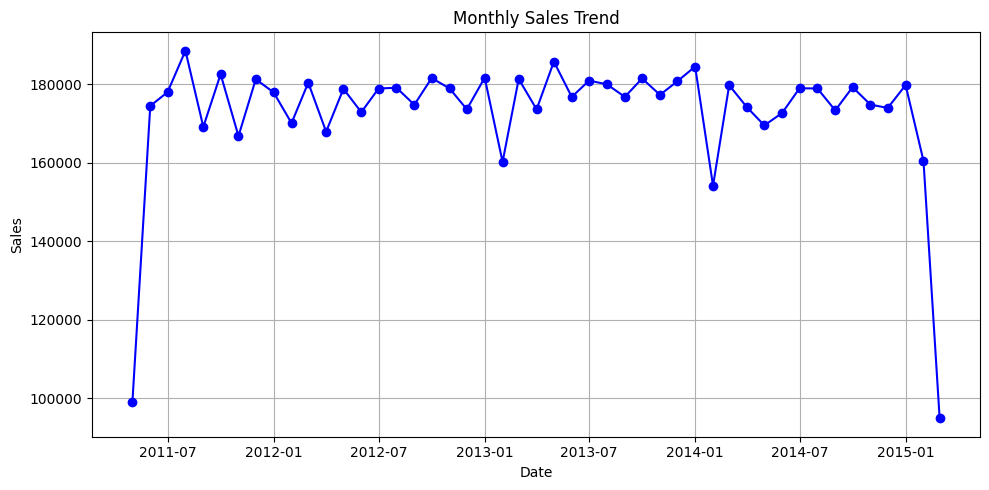

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales['period'], monthly_sales['tran_amount'], marker='o', color='blue')
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()
plt.savefig("sales_trend.png")  # Save to insert in PPT or Excel


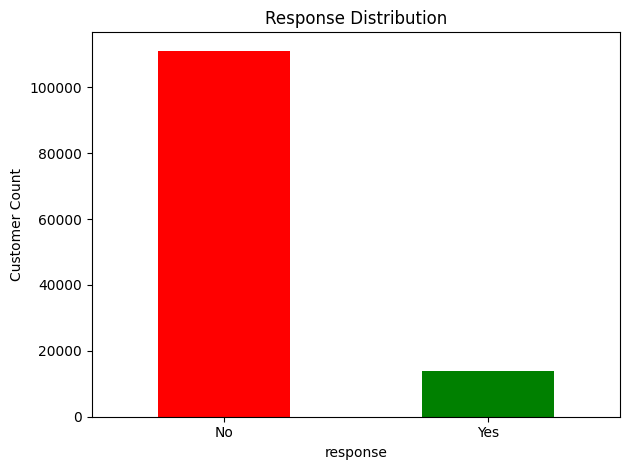

In [20]:
response_counts = merged_df['response'].value_counts()
response_counts.plot(kind='bar', color=['red', 'green'], title='Response Distribution')
plt.xticks(ticks=[0,1], labels=['No', 'Yes'], rotation=0)
plt.ylabel("Customer Count")
plt.tight_layout()
plt.savefig("response_distribution.png")
